# SHAP explainability, reframed (Phase 5, issue I-10 + I-12)

The original notebook's SHAP analysis ran on the label-buggy model and framed its top
features (obama, obamacar, socialist, ...) as evidence the model learned meaningful
deception cues. Rerun on the label-corrected text+metadata model, those features are
still topical/entity words -- which means the original framing was wrong regardless of
the label bug: **this is evidence of LIAR's topical bias, not a deception signal**, and
should be reported as a limitation, not a validation.

This notebook also fixes I-12 (unreadable stemmed feature labels like "obamacar",
"feder reserv") by mapping each stemmed token back to its most common surface form in
the training corpus before plotting, and adds a per-class breakdown (features pushing
toward *fake* specifically, not just overall importance).

**2026-08-25 update (explain the actual best model):** this notebook previously ran
SHAP on XGBoost, not on Naive Bayes -- the model `model_comparison_results_v3_metadata.csv`
and every paper draft report as the best overall configuration (text+metadata, no
speaker, test macro-F1 = 0.654). `ISSUE_PLAN.md`'s Phase 5 plan called for SHAP on "the
corrected best model"; the substitution was never intentional or documented. Fixed here:
the explained model is now exactly that Naive Bayes configuration (alpha=0.5, trained on
the merged train+validation pool per Section IV-C's protocol, no Chi2 reduction -- see
below for why none is needed), and `shap.TreeExplainer` is replaced with
`shap.LinearExplainer`, since Naive Bayes's log-odds decision function is linear in the
feature values (exact Shapley values, not an approximation).

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.naive_bayes import MultinomialNB

from liar_utils import evaluate_full, load_and_label, print_report
from metadata_features import METADATA_COLUMNS, _fillna_str, build_pipeline_transformer

import os

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

Load data (corrected labels), merge train+validation (Section IV-C's protocol for every
classical model in this paper), preprocess text + metadata

In [2]:
train_raw = load_and_label("train.csv")
valid_raw = load_and_label("valid.csv")
test = load_and_label("test.csv")

# Merge train+valid into the same fitting pool every classical model in this
# paper uses (Section IV-C), so the explained model matches Table II exactly.
train = pd.concat([train_raw, valid_raw], ignore_index=True)

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

# Track the most common surface form for each stem, so plots can show
# readable words instead of stemmed fragments (I-12).
surface_forms = Counter()


def preprocess(text, track_surface_forms=False):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    out = []
    for w in words:
        if w in stop_words:
            continue
        stem = stemmer.stem(w)
        if track_surface_forms:
            surface_forms[(stem, w)] += 1
        out.append(stem)
    return " ".join(out)


train["clean_text"] = train["Statement"].apply(lambda t: preprocess(t, track_surface_forms=True))
test["clean_text"] = test["Statement"].apply(preprocess)

train = _fillna_str(train, METADATA_COLUMNS)
test = _fillna_str(test, METADATA_COLUMNS)

y_train, y_test = train["Label"], test["Label"]

stem_to_surface = {}
best_count = {}
for (stem, surface), count in surface_forms.items():
    if stem not in best_count or count > best_count[stem]:
        best_count[stem] = count
        stem_to_surface[stem] = surface

Features: TF-IDF text + metadata, full feature space -- no Chi2 reduction. The previous
XGBoost setup reduced to k=1000 features partly for a readable/tractable tree-based SHAP
run; Naive Bayes's decision function is linear in the feature values, so exact
per-feature attributions are cheap to compute directly over the full space (see the
`shap.LinearExplainer` cell below), and this also matches Table II's actual winning
configuration, which uses no feature selection.

In [3]:
transformer = build_pipeline_transformer(use_metadata=True)
X_train = transformer.fit_transform(train)
X_test = transformer.transform(test)
feature_names = transformer.get_feature_names_out()

print("Feature matrix:", X_train.shape)

Feature matrix: (11524, 10728)


/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Readable display names: strip the ColumnTransformer prefix, map stemmed text tokens
back to their most common surface form

In [4]:
def display_name(raw_name):
    prefix, _, rest = raw_name.partition("__")
    if prefix == "text":
        words = rest.split(" ")
        words = [stem_to_surface.get(w, w) for w in words]
        return " ".join(words)
    if prefix == "subject":
        # Subject tags are otherwise bare words (e.g. "education") with no
        # distinguishing prefix, which would collide with plain text tokens
        # of the same surface form once whitespace-duplicate merging (below)
        # groups by display name -- explicitly namespaced to prevent a
        # topic tag and an unrelated word in the statement text from being
        # silently summed together as if they were the same feature.
        return f"Subject: {rest.strip()}"
    # Strip whitespace: a handful of raw metadata values (State, Context,
    # Speaker's job title) differ only by trailing/leading whitespace (e.g.
    # "Georgia", "Georgia ", "Georgia  " are three distinct raw strings, so
    # three distinct one-hot columns to the encoder) -- stripped here so they
    # display as the same category instead of looking like duplicates.
    name = rest.replace("_", ": ", 1).strip()
    # sklearn's OneHotEncoder(min_frequency=...) collapses rare categories
    # into a literal "infrequent_sklearn" placeholder value; relabel it to
    # something readable rather than leaking the internal sentinel string.
    if name.endswith("infrequent_sklearn"):
        col = name.split(":", 1)[0]
        name = f"{col}: (other, less common)"
    return name


display_names = np.array([display_name(n) for n in feature_names])
list(zip(feature_names[:10], display_names[:10]))

[('text__aaa', np.str_('aaa')),
 ('text__aarp', np.str_('aarp')),
 ('text__abandon', np.str_('abandoned')),
 ('text__abbott', np.str_('abbott')),
 ('text__abc', np.str_('abc')),
 ('text__abel', np.str_('abele')),
 ('text__abid', np.str_('abiding')),
 ('text__abil', np.str_('ability')),
 ('text__abl', np.str_('able')),
 ('text__abl bodi', np.str_('able body'))]

Fit the actual best model (Naive Bayes, alpha=0.5 -- Table II's winning hyperparameter
for this exact text+metadata configuration, already tuned via `GridSearchCV` in
`proposed_with_metadata_v1.ipynb`, so it is not re-tuned here, consistent with this
notebook's original policy of not re-optimizing performance)

In [5]:
best_model = MultinomialNB(alpha=0.5)
best_model.fit(X_train, y_train)

y_test_pred = best_model.predict(X_test)
print_report("Naive Bayes (text+metadata, alpha=0.5)", y_test, y_test_pred)
test_metrics = evaluate_full(y_test, y_test_pred)
print("Test macro-F1:", test_metrics["macro_f1"])


Naive Bayes (text+metadata, alpha=0.5)
[[314 239]
 [187 527]]
              precision    recall  f1-score   support

        fake      0.627     0.568     0.596       553
        real      0.688     0.738     0.712       714

    accuracy                          0.664      1267
   macro avg      0.657     0.653     0.654      1267
weighted avg      0.661     0.664     0.661      1267

Test macro-F1: 0.6539937945535669


SHAP -- exact `LinearExplainer`. Naive Bayes's log-odds decision function is linear in
the (TF-IDF + metadata) feature values: log[P(real|x)/P(fake|x)] =
(class\_log\_prior\_[real] - class\_log\_prior\_[fake]) + x . (feature\_log\_prob\_[real]
- feature\_log\_prob\_[fake]). This is exactly the form `shap.LinearExplainer` expects,
so the SHAP values below are the same closed-form Shapley values used for any linear
model -- not sampled or approximated the way `KernelExplainer` would be -- computed
against a background distribution estimated from a sample of the training set
(`feature_perturbation="interventional"`). Positive SHAP = pushes toward class 1 (real);
negative = pushes toward class 0 (fake), same convention as the original XGBoost run.

In [6]:
nb_coef = best_model.feature_log_prob_[1] - best_model.feature_log_prob_[0]
nb_intercept = best_model.class_log_prior_[1] - best_model.class_log_prior_[0]

masker = shap.maskers.Independent(X_train, max_samples=200)
explainer = shap.LinearExplainer((nb_coef, nb_intercept), masker)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1267, 10728)


Global importance (mean |SHAP|) -- FIGURE: save for the paper (`figures/shap_bar.png`)

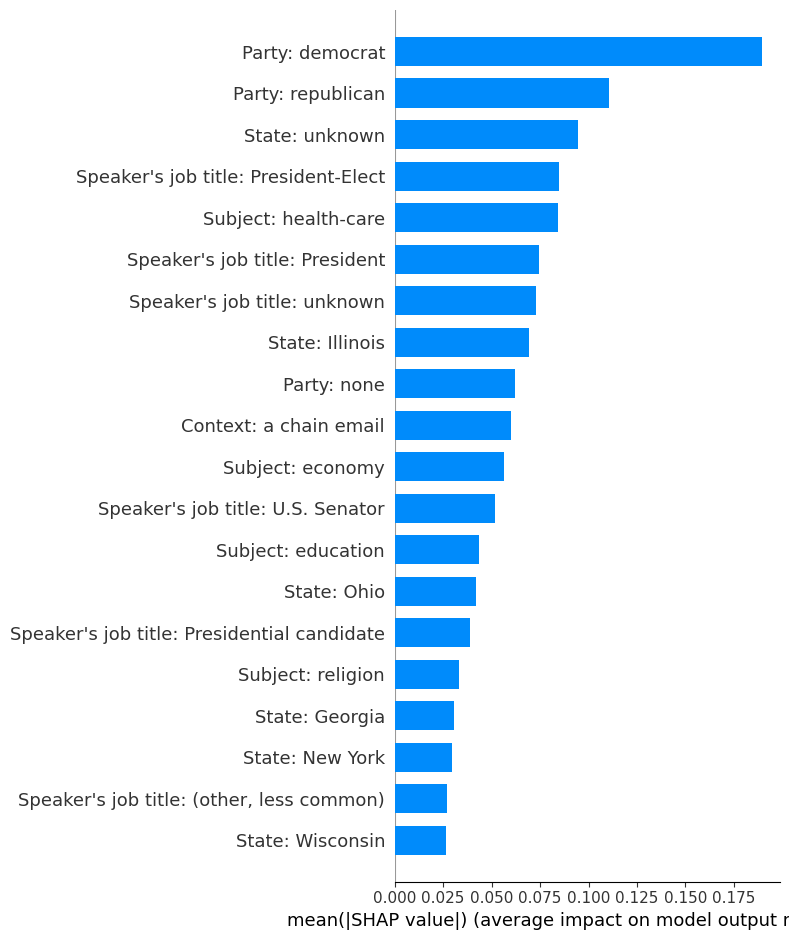

In [7]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=display_names, plot_type="bar", show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Beeswarm (distribution + direction) -- FIGURE: save for the paper (`figures/shap_beeswarm.png`)

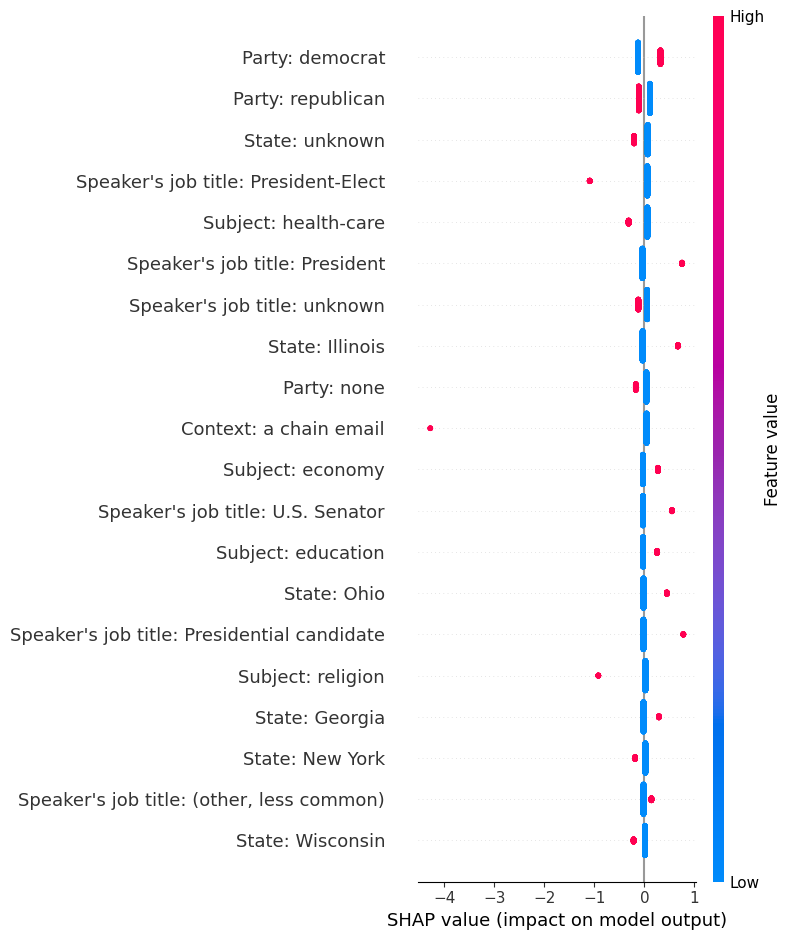

In [8]:
plt.figure()
shap.summary_plot(shap_values, X_test.toarray(), feature_names=display_names, show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Per-class breakdown (I-10): top features pushing toward *fake* specifically (most negative
mean SHAP) vs. toward *real* (most positive mean SHAP) -- not just overall |importance|

In [9]:
mean_shap = shap_values.mean(axis=0)
raw_importance_df = pd.DataFrame({"feature": display_names, "raw_feature": feature_names, "mean_shap": mean_shap})

# Whitespace-only variants of the same raw category (see display_name above)
# now share a display name; merge them by summing their per-feature mean
# SHAP (each test row has exactly one of the variants set, so this is the
# correct additive combination) rather than letting the same real-world
# category appear twice in the ranked list. This is a no-op for every
# feature that wasn't actually duplicated.
importance_df = (
    raw_importance_df.groupby("feature", as_index=False)
    .agg(mean_shap=("mean_shap", "sum"), raw_feature=("raw_feature", lambda s: "; ".join(s)))
)

top_fake = importance_df.sort_values("mean_shap").head(15).reset_index(drop=True)
top_real = importance_df.sort_values("mean_shap", ascending=False).head(15).reset_index(drop=True)

print("Top features pushing toward FAKE (label=0):")
print(top_fake[["feature", "mean_shap"]])
print("\nTop features pushing toward REAL (label=1):")
print(top_real[["feature", "mean_shap"]])

importance_df.sort_values("mean_shap").to_csv("shap_top_features_v1.csv", index=False)

Top features pushing toward FAKE (label=0):
                                      feature  mean_shap
0                              State: Georgia  -0.011133
1     Context: an interview on Meet the Press  -0.010857
2                            State: Wisconsin  -0.007848
3   Speaker's job title: Social media posting  -0.007723
4                             Context: a book  -0.007605
5   Speaker's job title: (other, less common)  -0.006923
6                Speaker's job title: Senator  -0.006218
7                          Subject: education  -0.005853
8               Subject: candidates-biography  -0.005672
9                         Subject: population  -0.005527
10                            Context: Denver  -0.005526
11        Speaker's job title: Representative  -0.005526
12                    Context: a chain e-mail  -0.005007
13                                      worst  -0.004906
14                          State: New Jersey  -0.004852

Top features pushing toward REAL (label=1):

Per-class bar chart -- FIGURE: save for the paper (`figures/shap_per_class.png`). Two-sided
bar: left = pushes toward fake, right = pushes toward real.

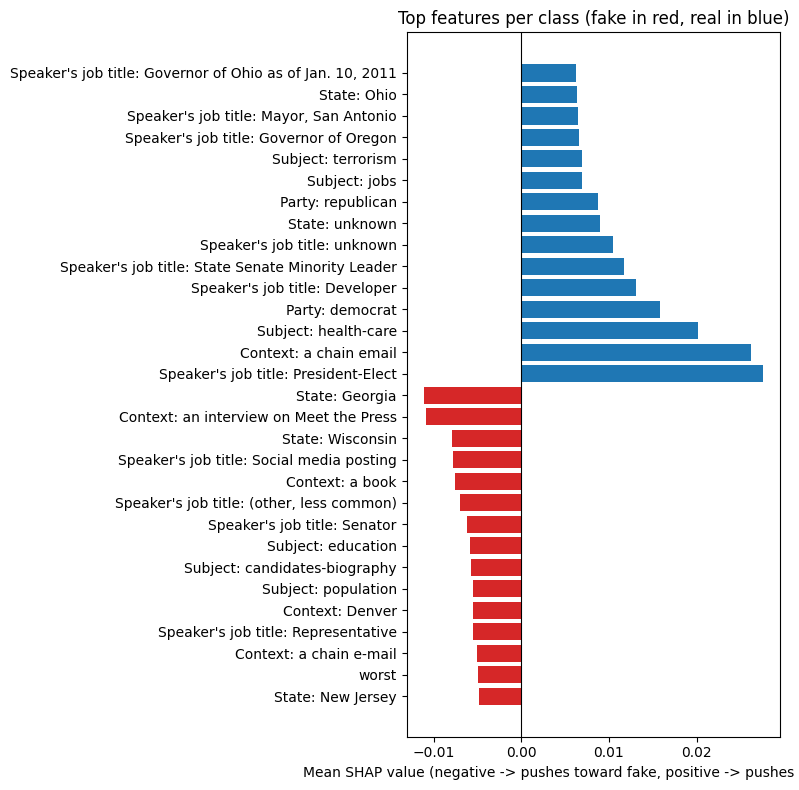

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
combined = pd.concat([top_fake.iloc[::-1], top_real])
colors = ["#d62728" if v < 0 else "#1f77b4" for v in combined["mean_shap"]]
ax.barh(combined["feature"], combined["mean_shap"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean SHAP value (negative -> pushes toward fake, positive -> pushes toward real)")
ax.set_title("Top features per class (fake in red, real in blue)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Qualitative examples -- one correctly classified fake statement, one correctly classified
real statement. FIGURES: `figures/shap_force_fake_example.png`, `figures/shap_force_real_example.png`

FAKE example statement: Says John McCain has done nothing to help the vets.
REAL example statement: Suzanne Bonamici supports a plan that will cut choice for Medicare Advantage seniors.


<Figure size 640x480 with 0 Axes>

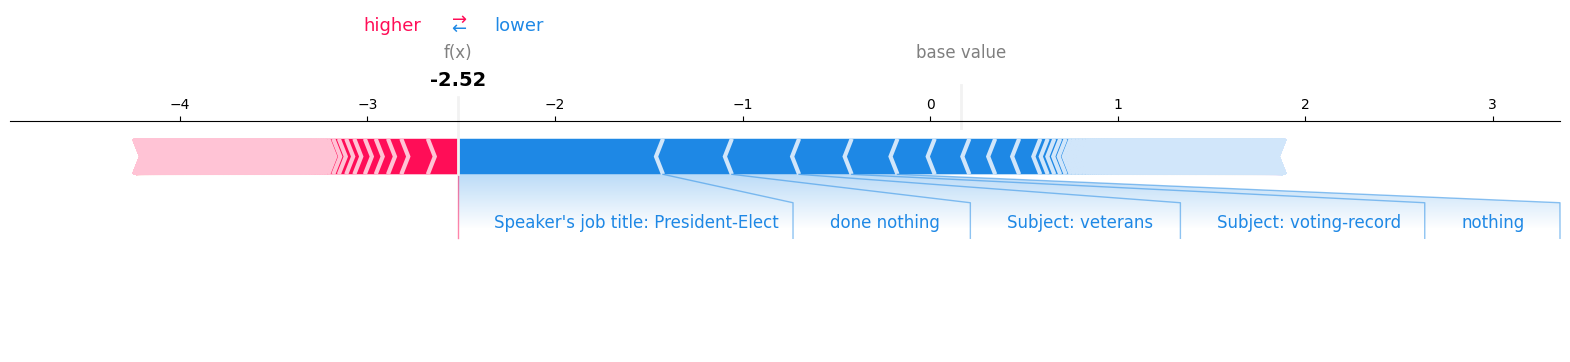

<Figure size 640x480 with 0 Axes>

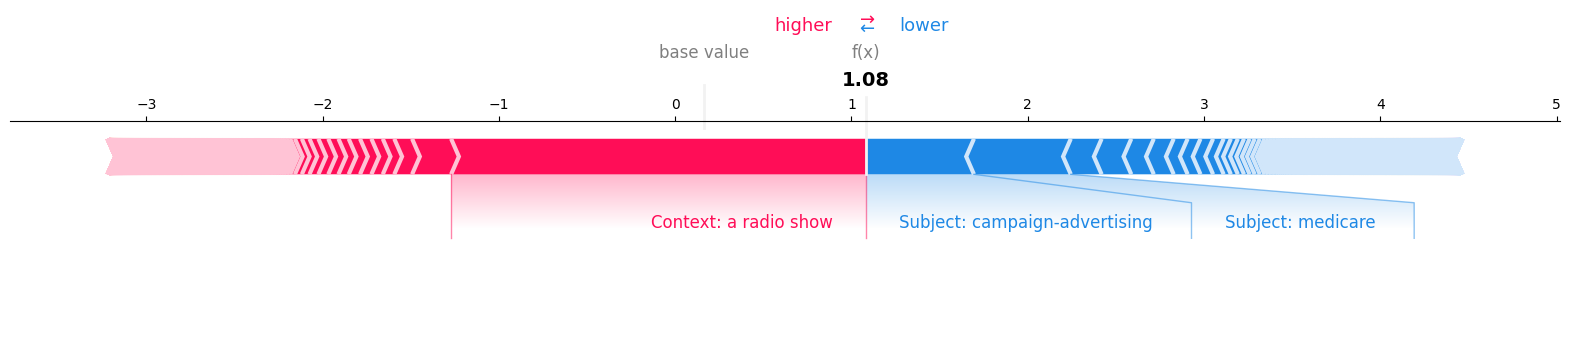

In [11]:
y_test_arr = np.asarray(y_test)
correct = y_test_pred == y_test_arr

fake_idx = np.where(correct & (y_test_arr == 0))[0][0]
real_idx = np.where(correct & (y_test_arr == 1))[0][0]

print("FAKE example statement:", test.iloc[fake_idx]["Statement"])
print("REAL example statement:", test.iloc[real_idx]["Statement"])

for name, idx in [("fake", fake_idx), ("real", real_idx)]:
    plt.figure()
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx],
        feature_names=display_names,
        matplotlib=True,
        show=False,
    )
    plt.savefig(f"{FIGURES_DIR}/shap_force_{name}_example.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

## Interpretation (reframed per I-10; updated 2026-08-25 for the Naive Bayes rerun)

The features most associated with each class are dominated by speaker identity, job
title, and context metadata rather than the statement's language itself. Fake-pushing
features include several state/context/job-title categories (`State: Georgia`,
`Context: an interview on Meet the Press`, `Speaker's job title: Social media posting`)
and topic tags (`Subject: education`, `Subject: candidates-biography`); real-pushing
features are dominated by specific, often low-frequency job titles (`Speaker's job
title: President-Elect`, `Developer`, `State Senate Minority Leader`, `Governor of
Oregon`) alongside both major parties (`Party: democrat` and `Party: republican` both
push toward *real*) and a handful of topic tags (`Subject: health-care`, `jobs`,
`terrorism`). Several of the real-pushing job titles are rare, few-speaker categories,
which more plausibly reflects that specific speaker's historical truthfulness rate in
this dataset than any generalizable signal tied to the job title itself.

One finding illustrates dataset noise especially clearly: `Context: a chain e-mail`
pushes toward *fake* while the differently-spelled `Context: a chain email` pushes
toward *real* -- the same real-world context, split by a spelling variant in the raw
metadata, landing on opposite sides of the decision. This is not a meaningful
distinction the model has learned; it is an artifact of unnormalized categorical
metadata.

As with the earlier XGBoost run, none of this constitutes a general deception signal:
**it should be reported as a dataset-bias and low-frequency-category-memorization
limitation**, not a validation of the model's reasoning. The model is substantially
keying on *who said it, in what context, and how that exact string was recorded* rather
than *how the statement is phrased*, which limits generalization to new speakers,
contexts, and metadata-entry conventions, and motivates future work on contextual or
stylistic features -- and on cleaner categorical metadata -- rather than pure lexical
ones.